# Apriori - Mineração de regras frequentes

In [2]:
#Usando a implementação do Apriori disponível na biblioteca mlxtend
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

### Exemplo ilustrado nos slides

In [4]:
#Formato de lista de listas (cada lista simula uma transação)
tranactions_exmplo  =   [['Pao','Leite', 'Manteiga'],
                         ['Pao','Leite','Acucar'],
                         ['Pao'],
                         ['Pao','Leite'],
                         ['Pao','Leite','Manteiga','Acucar']]

#Recurso da biblioteca mlxtend para codificar transações no padrão numpy array booleano - cada coluna é um item 
#e linhas indicam se esse item existe em uma transação.
te = TransactionEncoder()
encoded = te.fit(tranactions_exmplo).transform(tranactions_exmplo)
print(encoded)

dfExemplo = pd.DataFrame(encoded, columns=te.columns_)
dfExemplo


[[False  True  True  True]
 [ True  True False  True]
 [False False False  True]
 [False  True False  True]
 [ True  True  True  True]]


,Acucar,Leite,Manteiga,Pao
0,False,True,True,True
1,True,True,False,True
2,False,False,False,True
3,False,True,False,True
4,True,True,True,True


In [7]:
#Calcula os conjuntos de itens (itemsets) com suporte >= 0,4
frequent_itemsets = apriori(dfExemplo, min_support=0.4, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.4,(Acucar)
1,0.8,(Leite)
2,0.4,(Manteiga)
3,1.0,(Pao)
4,0.4,"(Leite, Acucar)"
5,0.4,"(Acucar, Pao)"
6,0.4,"(Leite, Manteiga)"
7,0.8,"(Leite, Pao)"
8,0.4,"(Manteiga, Pao)"
9,0.4,"(Leite, Acucar, Pao)"


## Exemplo com o dataset do filme Titanic

### Dataset e Preprocessamento 

In [9]:
dfTitanicFull = pd.read_csv('titanic.csv')


#Excluindo as features que não quero itentificar associações
dfTitanic = dfTitanicFull.drop(columns=['Name','Parents/Children Aboard','Siblings/Spouses Aboard','Fare'])

# Trocando os valores binários para um string
mudar_status = {0: "Morreu", 1: "Sobreviveu"}
dfTitanic.replace({'Survived' : mudar_status}, inplace=True)

mudar_classe = {1: "1-classe", 2: "2-classe", 3:"3-classe"}
dfTitanic.replace({'Pclass' : mudar_classe}, inplace=True)

#Criando labels para as idades
dfTitanic['Age'] = pd.cut(dfTitanic.Age,bins=[0,17,65,120],labels=['Crianca','Adulto','Idoso'])

dfTitanic


,Survived,Pclass,Sex,Age
0,Morreu,3-classe,male,Adulto
1,Sobreviveu,1-classe,female,Adulto
2,Sobreviveu,3-classe,female,Adulto
3,Sobreviveu,1-classe,female,Adulto
4,Morreu,3-classe,male,Adulto
...,...,...,...,...
882,Morreu,2-classe,male,Adulto
883,Sobreviveu,1-classe,female,Adulto
884,Morreu,3-classe,female,Crianca
885,Sobreviveu,1-classe,male,Adulto


### Transformações necessárias

In [10]:
transactions = []
numLines = dfTitanic.shape[0]
numColumns = dfTitanic.shape[1]

#Transforma para lista de listas (ideia de transações)
for i in range(0,numLines):
    transactions.append([str(dfTitanic.values[i,j]) for j in range(0,numColumns)])
    
#Recurso da biblioteca mlxtend para codificar transações -- explicado acima.
te = TransactionEncoder()
transEncoded = te.fit(transactions).transform(transactions)

df = pd.DataFrame(transEncoded, columns=te.columns_)
df


,1-classe,2-classe,3-classe,Adulto,Crianca,Idoso,Morreu,Sobreviveu,female,male
0,False,False,True,True,False,False,True,False,False,True
1,True,False,False,True,False,False,False,True,True,False
2,False,False,True,True,False,False,False,True,True,False
3,True,False,False,True,False,False,False,True,True,False
4,False,False,True,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
882,False,True,False,True,False,False,True,False,False,True
883,True,False,False,True,False,False,False,True,True,False
884,False,False,True,False,True,False,True,False,True,False
885,True,False,False,True,False,False,False,True,False,True


### Itemsets frequentes

In [11]:
#Itemsets frquequentes com um determinado suporte informado
frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)
print(frequent_itemsets.to_string())

     support                          itemsets
0   0.243517                        (1-classe)
1   0.207441                        (2-classe)
2   0.549042                        (3-classe)
3   0.842165                          (Adulto)
4   0.146561                         (Crianca)
5   0.614431                          (Morreu)
6   0.385569                      (Sobreviveu)
7   0.354002                          (female)
8   0.645998                            (male)
9   0.225479                (1-classe, Adulto)
10  0.153326            (Sobreviveu, 1-classe)
11  0.105975                (1-classe, female)
12  0.137542                  (male, 1-classe)
13  0.179256                (2-classe, Adulto)
14  0.109357                (2-classe, Morreu)
15  0.121759                  (male, 2-classe)
16  0.437430                (3-classe, Adulto)
17  0.107103               (3-classe, Crianca)
18  0.414882                (3-classe, Morreu)
19  0.134160            (3-classe, Sobreviveu)
20  0.162345 

### Regras de associação

In [12]:
#Regras com o valor de confiança mínimo escolhido
dfRegras= association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
dfRegras

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(1-classe),(Adulto),0.243517,0.842165,0.225479,0.925926,1.099460,0.020397,2.130778,0.119583
1,(1-classe),(Sobreviveu),0.243517,0.385569,0.153326,0.629630,1.632987,0.059433,1.658963,0.512405
2,(1-classe),(male),0.243517,0.645998,0.137542,0.564815,0.874329,-0.019769,0.813452,-0.159666
3,(2-classe),(Adulto),0.207441,0.842165,0.179256,0.864130,1.026083,0.004557,1.161669,0.032073
4,(2-classe),(Morreu),0.207441,0.614431,0.109357,0.527174,0.857988,-0.018101,0.815457,-0.172761
...,...,...,...,...,...,...,...,...,...,...
73,"(3-classe, Morreu)","(male, Adulto)",0.414882,0.559188,0.284104,0.684783,1.224601,0.052107,1.398437,0.313454
74,"(male, Adulto)","(3-classe, Morreu)",0.559188,0.414882,0.284104,0.508065,1.224601,0.052107,1.189421,0.416068
75,"(male, Morreu)","(3-classe, Adulto)",0.523112,0.437430,0.284104,0.543103,1.241579,0.055279,1.231286,0.408008
76,"(Adulto, Morreu)","(3-classe, male)",0.531003,0.386697,0.284104,0.535032,1.383595,0.078766,1.319022,0.591146


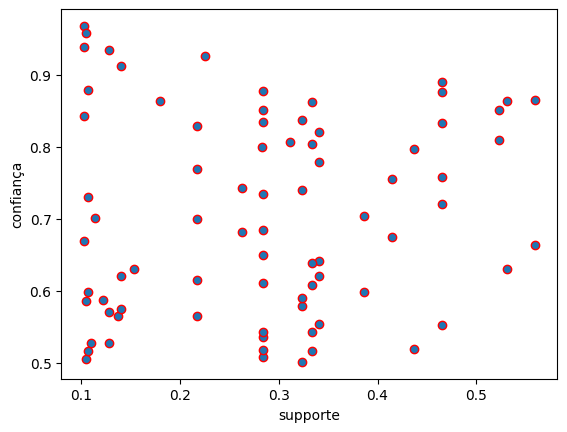

In [11]:
#Scatter plot da confiança e suporte. Auxilia no entendimento do espaço de regras
plt.scatter(data = dfRegras, x='support', y='confidence', edgecolors='red')
plt.xlabel('supporte')
plt.ylabel('confiança')
plt.show()

In [12]:
#Filtrando regras apenas com o consequente "Sobreviveu" ou "Morreu"
dfRegras[(dfRegras['consequents'] == {'Sobreviveu'}) | (dfRegras['consequents'] == {'Morreu'}) ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
1,(1-classe),(Sobreviveu),0.243517,0.385569,0.153326,0.629630,1.632987,0.059433,1.658963,0.512405
4,(2-classe),(Morreu),0.207441,0.614431,0.109357,0.527174,0.857988,-0.018101,0.815457,-0.172761
9,(3-classe),(Morreu),0.549042,0.614431,0.414882,0.755647,1.229833,0.077534,1.577918,0.414409
13,(Adulto),(Morreu),0.842165,0.614431,0.531003,0.630522,1.026189,0.013552,1.043552,0.161692
19,(male),(Morreu),0.645998,0.614431,0.523112,0.809773,1.317924,0.126191,2.026892,0.681439
21,(female),(Sobreviveu),0.354002,0.385569,0.262683,0.742038,1.924526,0.126191,2.381867,0.743643
23,"(Adulto, 1-classe)",(Sobreviveu),0.225479,0.385569,0.139797,0.620000,1.608012,0.052859,1.616923,0.488191
29,"(female, 1-classe)",(Sobreviveu),0.105975,0.385569,0.102593,0.968085,2.510794,0.061732,19.252161,0.673046
32,"(2-classe, Adulto)",(Morreu),0.179256,0.614431,0.104848,0.584906,0.951947,-0.005293,0.928872,-0.057940
37,"(2-classe, male)",(Morreu),0.121759,0.614431,0.102593,0.842593,1.371339,0.027781,2.449499,0.308327


In [13]:
#Conta quantos elementos tem no antecedente e armazena esse valor em "antecedent_len"
dfRegras["antecedent_len"] = dfRegras["antecedents"].apply(lambda x: len(x))

#Filtra regras com pelo menos dois elementos no antecedente, com lift>1 e consequente "Sobreviveu" ou "Morreu"
dfRegras[ (dfRegras['antecedent_len'] >= 2) &
          (dfRegras['lift'] > 1) &
          ((dfRegras['consequents'] == {'Sobreviveu'}) | (dfRegras['consequents'] == {'Morreu'}))]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,antecedent_len
24,"(1-classe, Adulto)",(Sobreviveu),0.225479,0.385569,0.139797,0.620000,1.608012,0.052859,1.616923,0.488191,2
30,"(1-classe, female)",(Sobreviveu),0.105975,0.385569,0.102593,0.968085,2.510794,0.061732,19.252161,0.673046,2
37,"(male, 2-classe)",(Morreu),0.121759,0.614431,0.102593,0.842593,1.371339,0.027781,2.449499,0.308327,2
39,"(3-classe, Adulto)",(Morreu),0.437430,0.614431,0.340474,0.778351,1.266783,0.071703,1.739545,0.374351,2
50,"(3-classe, male)",(Morreu),0.386697,0.614431,0.333709,0.862974,1.404510,0.096111,2.813836,0.469601,2
56,"(male, Adulto)",(Morreu),0.559188,0.614431,0.465614,0.832661,1.355175,0.122032,2.304125,0.594558,2
64,"(Adulto, female)",(Sobreviveu),0.282976,0.385569,0.217587,0.768924,1.994257,0.108480,2.659002,0.695319,2
67,"(3-classe, male, Adulto)",(Morreu),0.323563,0.614431,0.284104,0.878049,1.429045,0.085297,3.161669,0.443843,3


### Mesmo exemplo anterior usando fp-Growth

In [14]:
from mlxtend.frequent_patterns import fpgrowth

#Identifica conjuntos frequentes
frequentFpGrowth= fpgrowth(df, min_support=0.1, use_colnames=True)

#Itentifica regras
dfRegrasFP= association_rules(frequentFpGrowth, metric='confidence', min_threshold=0.5)

#Faz os mesmos filtros aplicados com o Apriori no exemplo acima
dfRegrasFP["antecedent_len"] = dfRegrasFP["antecedents"].apply(lambda x: len(x))
dfRegrasFP[ (dfRegrasFP['antecedent_len'] >= 2) &
            (dfRegrasFP['lift'] > 1) &
           ((dfRegrasFP['consequents'] == {'Sobreviveu'}) | (dfRegrasFP['consequents'] == {'Morreu'}))]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,antecedent_len
6,"(male, Adulto)",(Morreu),0.559188,0.614431,0.465614,0.832661,1.355175,0.122032,2.304125,0.594558,2
18,"(3-classe, Adulto)",(Morreu),0.437430,0.614431,0.340474,0.778351,1.266783,0.071703,1.739545,0.374351,2
23,"(3-classe, male)",(Morreu),0.386697,0.614431,0.333709,0.862974,1.404510,0.096111,2.813836,0.469601,2
34,"(3-classe, male, Adulto)",(Morreu),0.323563,0.614431,0.284104,0.878049,1.429045,0.085297,3.161669,0.443843,3
51,"(Adulto, female)",(Sobreviveu),0.282976,0.385569,0.217587,0.768924,1.994257,0.108480,2.659002,0.695319,2
59,"(1-classe, Adulto)",(Sobreviveu),0.225479,0.385569,0.139797,0.620000,1.608012,0.052859,1.616923,0.488191,2
62,"(1-classe, female)",(Sobreviveu),0.105975,0.385569,0.102593,0.968085,2.510794,0.061732,19.252161,0.673046,2
76,"(male, 2-classe)",(Morreu),0.121759,0.614431,0.102593,0.842593,1.371339,0.027781,2.449499,0.308327,2
